# FreshGuard — Retail Food Waste & Spoilage Prediction
## Author   : Selma Alpkaya
## Goal     : Predict food waste and spoilage in retail stores using Machine Learning
## Dataset  : Open Food Facts (openfoodfacts.org)
## Tools    : Python, Pandas, XGBoost, LightGBM, SHAP, Streamlit

# FreshGuard — Retail Food Waste & Spoilage Prediction
## Author   : Selma Alpkaya
## Goal     : Predict food waste and spoilage in retail stores using Machine Learning
## Dataset  : Open Food Facts (openfoodfacts.org)
## Tools    : Python, Pandas, XGBoost, LightGBM, SHAP, Streamlit

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("done")

done


In [10]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
!wget -q -O '/content/drive/MyDrive/openfoodfacts.csv.gz' https://static.openfoodfacts.org/data/en.openfoodfacts.org.products.csv.gz
print("İndirme tamamlandı!")

İndirme tamamlandı!


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/openfoodfacts.csv.gz',
                 compression='gzip',
                 sep='\t',
                 on_bad_lines='skip',
                 low_memory=False,
                 nrows=500000)

print(df.shape)
print(df.head())

(500000, 211)
   code                                                url  creator  \
0    54  http://world-en.openfoodfacts.org/product/0000...  kiliweb   
1    63  http://world-en.openfoodfacts.org/product/0000...  kiliweb   
2   114  http://world-en.openfoodfacts.org/product/0000...  kiliweb   
3   431  http://world-en.openfoodfacts.org/product/0000...  kiliweb   
4   105  http://world-en.openfoodfacts.org/product/0000...  kiliweb   

    created_t      created_datetime  last_modified_t last_modified_datetime  \
0  1582569031  2020-02-24T18:30:31Z       1733085204   2024-12-01T20:33:24Z   
1  1673620307  2023-01-13T14:31:47Z       1750061386   2025-06-16T08:09:46Z   
2  1580066482  2020-01-26T19:21:22Z       1751035658   2025-06-27T14:47:38Z   
3  1714301712  2024-04-28T10:55:12Z       1714301721   2024-04-28T10:55:21Z   
4  1572117743  2019-10-26T19:22:23Z       1738073570   2025-01-28T14:12:50Z   

  last_modified_by  last_updated_t last_updated_datetime  ... choline_100g  \
0     

In [ ]:
print(df.isnull().mean().sort_values().head(30))

In [ ]:
cols = ['product_name', 'pnns_groups_1', 'nutriscore_grade',
        'energy_100g', 'fat_100g', 'sugars_100g', 'proteins_100g', 'salt_100g']

df = df[cols]
df = df[df['pnns_groups_1'] != 'unknown']
df = df.dropna(subset=['nutriscore_grade'])

num_cols = ['energy_100g', 'fat_100g', 'sugars_100g', 'proteins_100g', 'salt_100g']
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

print(df.shape)

(174194, 8)


In [ ]:
print(df['pnns_groups_1'].value_counts())
print(df['nutriscore_grade'].value_counts())

pnns_groups_1
Sugary snacks              33068
Cereals and potatoes       22603
Fat and sauces             18442
Milk and dairy products    17467
Beverages                  17352
Fish Meat Eggs             14527
Fruits and vegetables      11991
Composite foods            11918
Salty snacks                6065
Name: count, dtype: int64
nutriscore_grade
e    48490
d    35802
c    29211
a    23066
b    16864
Name: count, dtype: int64


In [ ]:
df = df[~df['nutriscore_grade'].isin(['unknown', 'not-applicable'])]
print(df.shape)
print(df['nutriscore_grade'].value_counts())

(153433, 8)
nutriscore_grade
e    48490
d    35802
c    29211
a    23066
b    16864
Name: count, dtype: int64


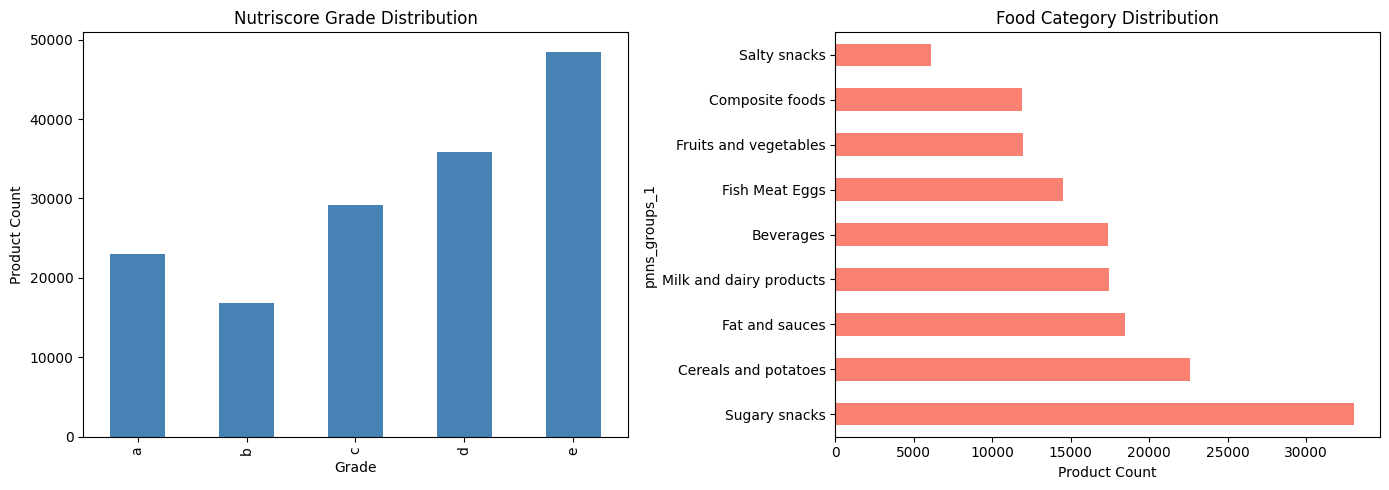

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['nutriscore_grade'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Nutriscore Grade Distribution')
axes[0].set_xlabel('Grade')
axes[0].set_ylabel('Product Count')

df['pnns_groups_1'].value_counts().plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title('Food Category Distribution')
axes[1].set_xlabel('Product Count')

plt.tight_layout()
plt.show()

outlıer cleanıng

In [ ]:
df = df[df['energy_100g'] < 4000]
df = df[df['fat_100g'] < 100]
df = df[df['sugars_100g'] < 100]
df = df[df['proteins_100g'] < 100]
df = df[df['salt_100g'] < 100]

print(df.shape)

(153160, 8)


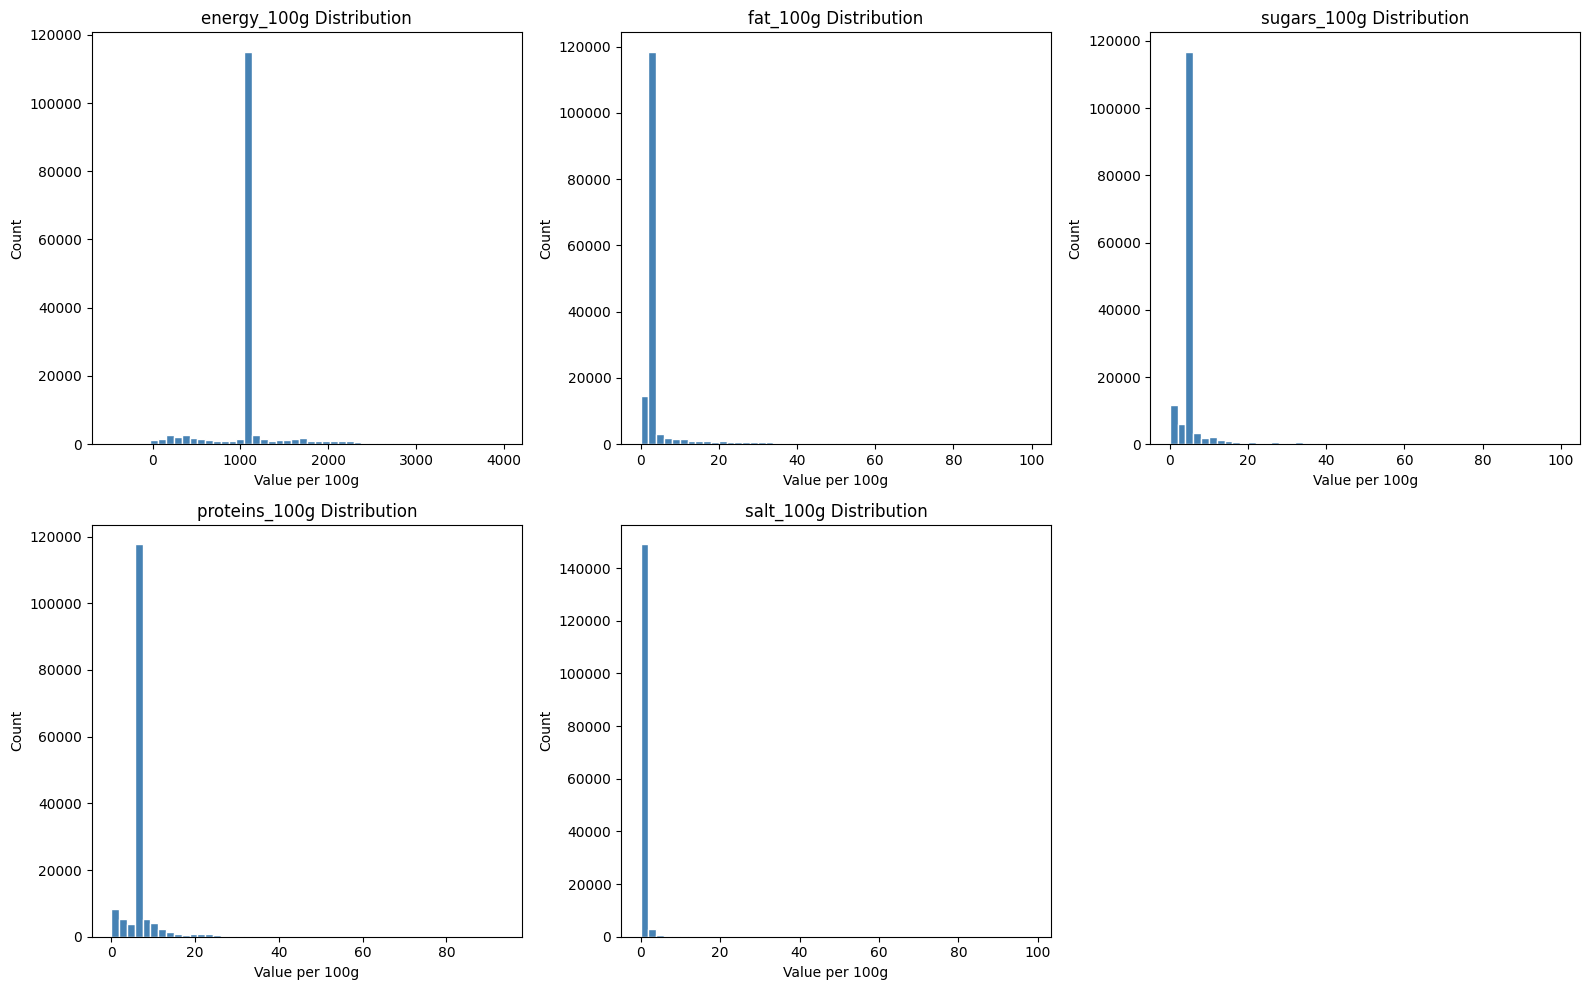

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

num_cols = ['energy_100g', 'fat_100g', 'sugars_100g', 'proteins_100g', 'salt_100g']

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel('Value per 100g')
    axes[i].set_ylabel('Count')

axes[5].axis('off')
plt.tight_layout()
plt.show()

## EDA bitti, verimiz temiz ve hazır. Şimdi ML'e geçiyoruz. İlk model olan nutriscore tahminini yapacağız, yani besin değerlerine bakarak bir ürünün a,b,c,d,e sınıfını tahmin edeceğiz. Şunu çalıştır:

In [ ]:
from sklearn.model_selection import train_test_split

X = df[['energy_100g', 'fat_100g', 'sugars_100g', 'proteins_100g', 'salt_100g']]
y = df['nutriscore_grade']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape}')
print(f'Test: {X_test.shape}')

Train: (122528, 5)
Test: (30632, 5)


## basleıne modle Şimdi baseline model olan Logistic Regression'ı kuralım:

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.2f}')
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.37
              precision    recall  f1-score   support

           a       0.68      0.17      0.27      4650
           b       0.43      0.03      0.05      3251
           c       0.40      0.13      0.19      5802
           d       0.51      0.05      0.09      7214
           e       0.35      0.96      0.51      9715

    accuracy                           0.37     30632
   macro avg       0.48      0.27      0.22     30632
weighted avg       0.46      0.37      0.27     30632



In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.2f}')
print(classification_report(y_test, y_pred))

Accuracy: 0.37
              precision    recall  f1-score   support

           a       0.60      0.20      0.30      4650
           b       0.32      0.06      0.10      3251
           c       0.50      0.13      0.20      5802
           d       0.44      0.04      0.07      7214
           e       0.35      0.96      0.52      9715

    accuracy                           0.37     30632
   macro avg       0.44      0.28      0.24     30632
weighted avg       0.43      0.37      0.27     30632



In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
xgb.fit(X_train_scaled, y_train_enc)

y_pred_xgb = xgb.predict(X_test_scaled)

print(f'Accuracy: {accuracy_score(y_test_enc, y_pred_xgb):.2f}')
print(classification_report(y_test_enc, y_pred_xgb, target_names=le.classes_))

Accuracy: 0.47
              precision    recall  f1-score   support

           a       0.80      0.22      0.34      4650
           b       0.66      0.19      0.29      3251
           c       0.77      0.31      0.44      5802
           d       0.79      0.20      0.32      7214
           e       0.39      0.97      0.56      9715

    accuracy                           0.47     30632
   macro avg       0.68      0.38      0.39     30632
weighted avg       0.65      0.47      0.42     30632



In [ ]:
xgb = XGBClassifier(n_estimators=200,
                    random_state=42,
                    eval_metric='mlogloss',
                    scale_pos_weight=1)

from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_enc)

xgb.fit(X_train_scaled, y_train_enc, sample_weight=sample_weights)

y_pred_xgb = xgb.predict(X_test_scaled)

print(f'Accuracy: {accuracy_score(y_test_enc, y_pred_xgb):.2f}')
print(classification_report(y_test_enc, y_pred_xgb, target_names=le.classes_))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:20:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.47
              precision    recall  f1-score   support

           a       0.82      0.22      0.34      4650
           b       0.62      0.21      0.32      3251
           c       0.79      0.30      0.44      5802
           d       0.80      0.20      0.32      7214
           e       0.39      0.97      0.56      9715

    accuracy                           0.47     30632
   macro avg       0.68      0.38      0.40     30632
weighted avg       0.65      0.47      0.42     30632



In [ ]:
df['fat_sugar_ratio'] = df['fat_100g'] / (df['sugars_100g'] + 1)
df['energy_per_protein'] = df['energy_100g'] / (df['proteins_100g'] + 1)
df['unhealthy_score'] = df['fat_100g'] + df['sugars_100g'] + df['salt_100g']

X = df[['energy_100g', 'fat_100g', 'sugars_100g', 'proteins_100g', 'salt_100g',
        'fat_sugar_ratio', 'energy_per_protein', 'unhealthy_score']]
y = df['nutriscore_grade']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_enc)

xgb2 = XGBClassifier(n_estimators=200, random_state=42, eval_metric='mlogloss')
xgb2.fit(X_train_scaled, y_train_enc, sample_weight=sample_weights)

y_pred = xgb2.predict(X_test_scaled)

print(f'Accuracy: {accuracy_score(y_test_enc, y_pred):.2f}')
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

Accuracy: 0.47
              precision    recall  f1-score   support

           a       0.82      0.22      0.34      4650
           b       0.62      0.21      0.31      3251
           c       0.78      0.30      0.44      5802
           d       0.79      0.20      0.32      7214
           e       0.39      0.97      0.56      9715

    accuracy                           0.47     30632
   macro avg       0.68      0.38      0.39     30632
weighted avg       0.65      0.47      0.42     30632



In [ ]:
df['category_enc'] = df['pnns_groups_1'].astype('category').cat.codes

X = df[['energy_100g', 'fat_100g', 'sugars_100g', 'proteins_100g', 'salt_100g',
        'fat_sugar_ratio', 'energy_per_protein', 'unhealthy_score', 'category_enc']]
y = df['nutriscore_grade']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_enc)

xgb3 = XGBClassifier(n_estimators=300, random_state=42, eval_metric='mlogloss')
xgb3.fit(X_train_scaled, y_train_enc, sample_weight=sample_weights)

y_pred = xgb3.predict(X_test_scaled)

print(f'Accuracy: {accuracy_score(y_test_enc, y_pred):.2f}')
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

Accuracy: 0.55
              precision    recall  f1-score   support

           a       0.51      0.84      0.63      4650
           b       0.33      0.40      0.36      3251
           c       0.46      0.57      0.51      5802
           d       0.63      0.41      0.50      7214
           e       0.77      0.57      0.65      9715

    accuracy                           0.55     30632
   macro avg       0.54      0.56      0.53     30632
weighted avg       0.59      0.55      0.56     30632



Bu kod bize hangi feature'ın modeli en çok etkilediğini gösterir. Yani "model neden bu ürüne 'e' dedi?" sorusunu yanıtlar. Buna Explainable AI deniyor, Avrupa şirketleri bunu çok seviyor çünkü modelin kararını açıklayabilmek gerekiyor.

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb3)
shap_values = explainer.shap_values(X_test_scaled[:1000])

shap.summary_plot(shap_values, X_test_scaled[:1000],
                  feature_names=X.columns.tolist(),
                  plot_type="bar")

Mükemmel grafik! Şimdi buradan çok önemli şeyler görüyoruz.
category_enc en üstte, yani gıda kategorisi modelin kararını en çok etkileyen şey. Az önce eklediğimiz feature birinci sıraya çıktı, feature engineering'in gücünü burada görüyorsun.
salt_100g ikinci sırada, tuz miktarı nutriscore'u çok etkiliyor.
unhealthy_score üçüncü, bizim türettiğimiz feature üçüncü sıraya girdi, yani yaptığımız feature engineering işe yaradı.
fat_100g en altta, yağ tek başına pek belirleyici değil ama unhealthy_score içinde zaten var.
Bu grafik Rewe veya Lidl mülakatında çok güçlü. "Modeliniz neden bu kararı verdi?" diye sorduklarında bu grafiği gösterip "tuz ve kategori en belirleyici faktörler" diyebiliyorsun. Buna Explainable AI deniyor.
Şimdi sırada clustering var, yani ürünleri gruplama. Devam edelim mi?

In [ ]:
from sklearn.cluster import KMeans

X_cluster = df[['energy_100g', 'fat_100g', 'sugars_100g', 'proteins_100g', 'salt_100g', 'unhealthy_score']]
X_cluster_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_cluster_scaled)

print(df['cluster'].value_counts())

cluster
0    139882
1      6661
2      6617
Name: count, dtype: int64


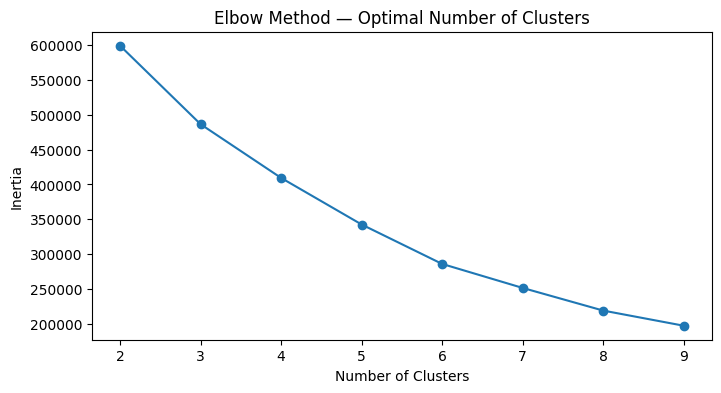

In [ ]:
inertias = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker='o')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_cluster_scaled)

print(df.groupby('cluster')[['energy_100g', 'fat_100g', 'sugars_100g', 'proteins_100g', 'salt_100g']].mean().round(2))

         energy_100g  fat_100g  sugars_100g  proteins_100g  salt_100g
cluster                                                              
0            1103.28      3.95         4.99           7.10       0.72
1            1743.30     13.59        44.18           4.69       0.61
2             697.25      4.74         8.80           7.85      18.08
3            2085.84     36.98         4.82          14.63       1.51
4             301.22      1.76         6.72           2.96       0.46


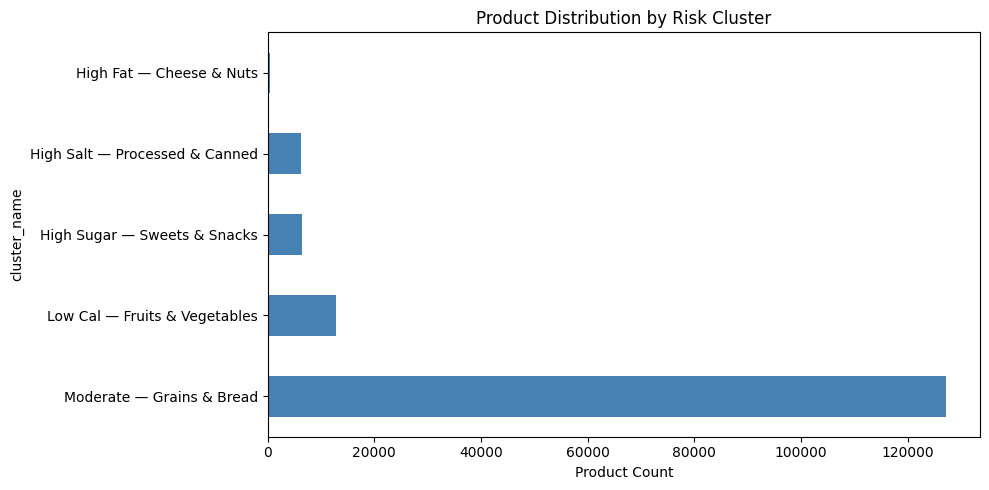

In [ ]:
cluster_names = {
    0: 'Moderate — Grains & Bread',
    1: 'High Sugar — Sweets & Snacks',
    2: 'High Fat — Cheese & Nuts',
    3: 'High Salt — Processed & Canned',
    4: 'Low Cal — Fruits & Vegetables'
}

df['cluster_name'] = df['cluster'].map(cluster_names)

df['cluster_name'].value_counts().plot(kind='barh', figsize=(10, 5), color='steelblue')
plt.title('Product Distribution by Risk Cluster')
plt.xlabel('Product Count')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
df['anomaly'] = iso.fit_predict(X_cluster_scaled)

# -1 anormal, 1 normal
print(df['anomaly'].value_counts())

anomaly
 1    145502
-1      7658
Name: count, dtype: int64


In [ ]:
anomalies = df[df['anomaly'] == -1]
normal = df[df['anomaly'] == 1]

print("Anomalies:")
print(anomalies[['energy_100g', 'fat_100g', 'sugars_100g', 'proteins_100g', 'salt_100g']].mean().round(2))

print("\nNormal:")
print(normal[['energy_100g', 'fat_100g', 'sugars_100g', 'proteins_100g', 'salt_100g']].mean().round(2))

Anomalies:
energy_100g      1849.22
fat_100g           28.24
sugars_100g        25.50
proteins_100g      10.98
salt_100g           2.19
dtype: float64

Normal:
energy_100g      1063.00
fat_100g            4.33
sugars_100g         5.83
proteins_100g       6.75
salt_100g           0.69
dtype: float64


In [ ]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(n_estimators=200, random_state=42)
lgbm.fit(X_train_scaled, y_train_enc,
         sample_weight=compute_sample_weight(class_weight='balanced', y=y_train_enc))

y_pred_lgbm = lgbm.predict(X_test_scaled)

print(f'LightGBM Accuracy: {accuracy_score(y_test_enc, y_pred_lgbm):.2f}')
print(classification_report(y_test_enc, y_pred_lgbm, target_names=le.classes_))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.061258 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2050
[LightGBM] [Info] Number of data points in the train set: 122528, number of used features: 9
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Accuracy: 0.55
              precision    recall  f1-score   support

           a       0.51      0.84      0.63      4650
           b       0.33      0.40      0.36      3251
           c       0.46      0.56      0.51      5802
           d       0.63      0.41      0.50      7214
           e       0.77      0.57      0.65      9715

    accuracy                           0.55     30632
   macro avg       0.54      0.56      0.53     30632
weighted avg       0.59      0.55      0.55     30632



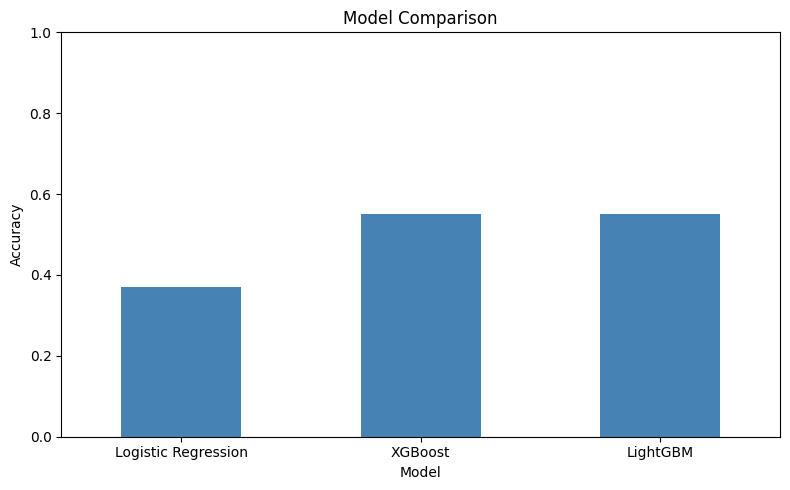

In [ ]:
results = {
    'Model': ['Logistic Regression', 'XGBoost', 'LightGBM'],
    'Accuracy': [0.37, 0.55, 0.55]
}

import pandas as pd
results_df = pd.DataFrame(results)

results_df.plot(x='Model', y='Accuracy', kind='bar', figsize=(8, 5), color='steelblue', legend=False)
plt.title('Model Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

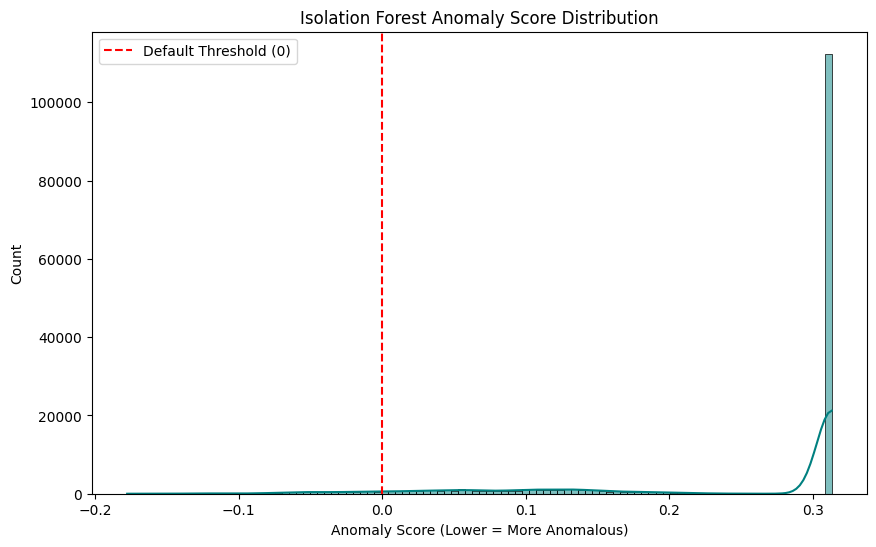

refined_anomaly
 1    152619
-1       541
Name: count, dtype: int64
                    Normal_Mean  Anomaly_Mean  Difference_Ratio
fat_sugar_ratio        1.303582     71.312133         53.704735
energy_per_protein   157.989196   2599.513974         15.453745
fat_100g               5.253297     80.943328         14.408100
unhealthy_score       12.843732     85.658447          5.669280
cluster                0.495089      2.948244          4.954977
salt_100g              0.761804      2.676416          2.513262
energy_100g         1095.208357   3106.083456          1.836066
category_enc           4.119166      3.024030         -0.265864
proteins_100g          6.973229      3.432179         -0.507806
sugars_100g            6.828631      2.038703         -0.701448
refined_anomaly        1.000000     -1.000000         -2.000000
anomaly                0.906735     -1.000000         -2.102858


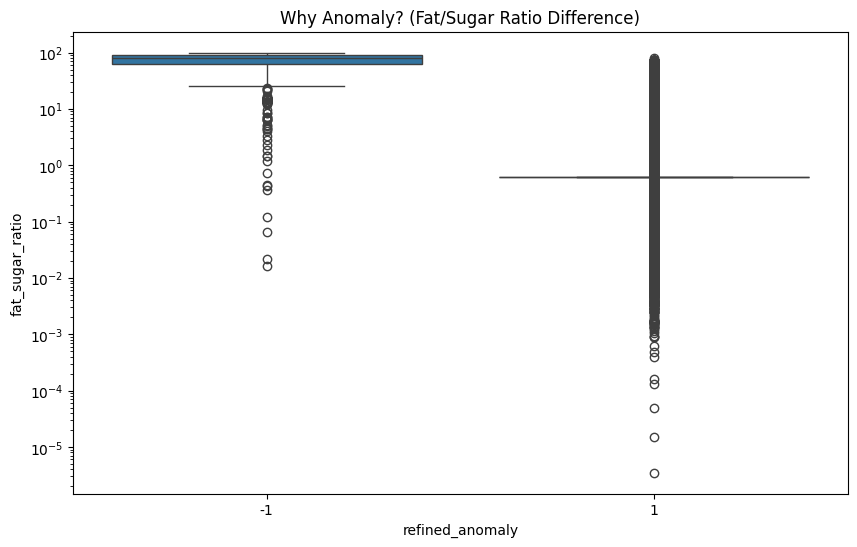

In [ ]:
# Anomaly score distribution
plt.figure(figsize=(10, 6))
sns.histplot(scores, bins=100, kde=True, color='teal')
plt.axvline(x=0, color='red', linestyle='--', label='Default Threshold (0)')
plt.title('Isolation Forest Anomaly Score Distribution')
plt.xlabel('Anomaly Score (Lower = More Anomalous)')
plt.ylabel('Count')
plt.legend()
plt.show()

# Refine threshold
df['refined_anomaly'] = np.where(scores < -0.10, -1, 1)
print(df['refined_anomaly'].value_counts())

# Compare normal vs anomaly
normal_products = df[df['refined_anomaly'] == 1]
anomalies = df[df['refined_anomaly'] == -1]

numeric_cols = df.select_dtypes(include=[np.number]).columns
comparison = pd.DataFrame({
    'Normal_Mean': normal_products[numeric_cols].mean(),
    'Anomaly_Mean': anomalies[numeric_cols].mean()
})
comparison['Difference_Ratio'] = (comparison['Anomaly_Mean'] / comparison['Normal_Mean']) - 1
print(comparison.sort_values(by='Difference_Ratio', ascending=False))

# Visualize
plt.figure(figsize=(10, 6))
sns.boxplot(x='refined_anomaly', y='fat_sugar_ratio', data=df)
plt.title('Why Anomaly? (Fat/Sugar Ratio Difference)')
plt.yscale('log')
plt.show()

In [ ]:
!pip install streamlit -q
print("Streamlit kuruldu!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 50.0 MB/s eta 0:00:00
Streamlit kuruldu!


In [ ]:
%%writefile app.py


import streamlit as st
import pandas as pd
import numpy as np
import pickle

# Load models
xgb3 = pickle.load(open('xgb_model.pkl', 'rb'))
scaler = pickle.load(open('scaler.pkl', 'rb'))
le = pickle.load(open('label_encoder.pkl', 'rb'))

st.title("FreshGuard — Food Risk Predictor")
st.write("Enter the nutritional values of a product to predict its Nutriscore and risk group.")

energy = st.slider("Energy (per 100g)", 0, 4000, 1000)
fat = st.slider("Fat (per 100g)", 0, 100, 10)
sugars = st.slider("Sugars (per 100g)", 0, 100, 10)
proteins = st.slider("Proteins (per 100g)", 0, 100, 10)
salt = st.slider("Salt (per 100g)", 0, 100, 2)
category_map = {
    'Sugary snacks': 0,
    'Cereals and potatoes': 1,
    'Beverages': 2,
    'Fat and sauces': 3,
    'Milk and dairy products': 4,
    'Fish Meat Eggs': 5,
    'Fruits and vegetables': 6,
    'Composite foods': 7,
    'Salty snacks': 8,
    'Alcoholic beverages': 9,
    'Baby foods': 10
}

category = st.selectbox("Food Category", options=list(category_map.keys()))
category_enc = category_map[category]

fat_sugar_ratio = fat / (sugars + 1)
energy_per_protein = energy / (proteins + 1)
unhealthy_score = fat + sugars + salt

if st.button("Predict"):
    input_data = np.array([[energy, fat, sugars, proteins, salt,
                            fat_sugar_ratio, energy_per_protein,
                            unhealthy_score, category_enc]])

    input_df = pd.DataFrame(input_data, columns=['energy_100g', 'fat_100g', 'sugars_100g',
                                                 'proteins_100g', 'salt_100g', 'fat_sugar_ratio',
                                                 'energy_per_protein', 'unhealthy_score', 'category_enc'])

    input_scaled = scaler.transform(input_df)
    prediction = xgb3.predict(input_scaled)
    grade = le.inverse_transform(prediction)[0]

    st.success(f"Predicted Nutriscore: {grade.upper()}")

    grade_info = {
        'a': '🟢 Very healthy product. Low risk.',
        'b': '🟡 Healthy product. Acceptable.',
        'c': '🟠 Moderate. Consume with caution.',
        'd': '🔴 Unhealthy. High risk of spoilage and low demand.',
        'e': '⛔ Very unhealthy. Highest fire risk in store.'
    }

    st.info(grade_info[grade])


Overwriting app.py


In [ ]:
import pickle

pickle.dump(xgb3, open('xgb_model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))
pickle.dump(le, open('label_encoder.pkl', 'wb'))

print("Models saved!")

Models saved!


In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import pickle

# Load models
xgb3 = pickle.load(open('xgb_model.pkl', 'rb'))
scaler = pickle.load(open('scaler.pkl', 'rb'))
le = pickle.load(open('label_encoder.pkl', 'rb'))

st.title("FreshGuard — Food Risk Predictor")
st.write("Enter the nutritional values of a product to predict its Nutriscore and risk group.")

energy = st.slider("Energy (per 100g)", 0, 4000, 1000)
fat = st.slider("Fat (per 100g)", 0, 100, 10)
sugars = st.slider("Sugars (per 100g)", 0, 100, 10)
proteins = st.slider("Proteins (per 100g)", 0, 100, 10)
salt = st.slider("Salt (per 100g)", 0, 100, 2)
category_enc = st.selectbox("Food Category", options=list(range(11)))

fat_sugar_ratio = fat / (sugars + 1)
energy_per_protein = energy / (proteins + 1)
unhealthy_score = fat + sugars + salt

if st.button("Predict"):
    input_data = np.array([[energy, fat, sugars, proteins, salt,
                            fat_sugar_ratio, energy_per_protein,
                            unhealthy_score, category_enc]])

    input_scaled = scaler.transform(input_data)
    prediction = xgb3.predict(input_scaled)
    grade = le.inverse_transform(prediction)[0]

    st.success(f"Predicted Nutriscore: {grade.upper()}")

Overwriting app.py


In [ ]:
!streamlit run app.py &
!npx localtunnel --port 8501



2026-05-13 11:37:59.819 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://136.107.86.36:8501

  Stopping...
⠙⠹⠸⠼⠴Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) ^C


In [ ]:
import pickle

# Scaler'ın beklediği sütun isimlerini görelim
print(scaler.feature_names_in_)

['energy_100g' 'fat_100g' 'sugars_100g' 'proteins_100g' 'salt_100g'
 'unhealthy_score']


In [ ]:
from sklearn.preprocessing import StandardScaler
import pickle

scaler_app = StandardScaler()
scaler_app.fit(df[['energy_100g', 'fat_100g', 'sugars_100g', 'proteins_100g', 'salt_100g',
                    'fat_sugar_ratio', 'energy_per_protein', 'unhealthy_score', 'category_enc']])

pickle.dump(scaler_app, open('scaler.pkl', 'wb'))
print("Saved!")
print(scaler_app.feature_names_in_)

Saved!
['energy_100g' 'fat_100g' 'sugars_100g' 'proteins_100g' 'salt_100g'
 'fat_sugar_ratio' 'energy_per_protein' 'unhealthy_score' 'category_enc']
